# 04 — Fragility Curves & Damage Probabilities

**Purpose:** Demonstrate the full workflow from fragility parameter database to
damage probability computation, showing how each bridge is matched to its
fragility curve.

## Input Files

| File | Format | Description |
|------|--------|-------------|
| `data/hazus_bridge_fragility_params.csv` | CSV | 28 HWB classes × 4 damage states, columns: median & beta |
| `config.yaml` | YAML | IM type, region bounds |
| `data/grid.xml` | XML (ShakeMap) | Ground motion grid for IM interpolation |
| `data/CA24.txt` | Fixed-width text (NBI) | Bridge inventory (material, design, spans → HWB class) |

## Workflow

```
CSV database (28 rows)          NBI bridge record
       ↓                               ↓
  Load all parameters          classify_nbi_to_hazus()
       ↓                               ↓
  HAZUS_BRIDGE_FRAGILITY        hwb_class = "HWB17"
       ↓                               ↓
       └──────── Lookup ────────────────┘
                    ↓
          {slight: {median: 0.25, beta: 0.6}, ...}
                    ↓
          fragility_curve() → exceedance probabilities
                    ↓
          damage_state_probabilities() → discrete P(ds)
```

## Expected Plots

- **Full parameter heatmap** — all 28 HWB classes × 4 medians
- **Single-bridge fragility curve** — 4 curves for a specific real bridge
- **Damage distribution bar chart** — portfolio-level expected counts

**Key concepts:** Lognormal fragility model P[DS ≥ ds | IM] = Φ[(ln(IM) − ln(median)) / β],
NBI → HWB class mapping, parameter lookup, exceedance vs discrete probability

## Imports & Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import load_config, IM_COLUMN_MAP
from src.data_loader import load_shakemap, load_nbi, classify_nbi_to_hazus
from src.interpolation import interpolate_im
from src.hazus_params import HAZUS_BRIDGE_FRAGILITY, DAMAGE_STATE_ORDER
from src.fragility import fragility_curve, compute_all_curves, damage_state_probabilities

%matplotlib inline

## Step 1: Load Fragility Parameter Database

The fragility parameters are stored in two forms:
1. **CSV file** (`data/hazus_bridge_fragility_params.csv`) — flat table, 28 rows × 10 columns
2. **Python dict** (`HAZUS_BRIDGE_FRAGILITY`) — nested lookup structure

Both contain the same data from Hazus 6.1 Table 7.9. We first load the CSV
to show the raw data, then demonstrate the dict-based lookup used in the pipeline.

In [2]:
# --- Method 1: Load from CSV file ---
csv_path = PROJECT_ROOT / "data" / "hazus_bridge_fragility_params.csv"
frag_csv = pd.read_csv(csv_path)
print(f"CSV file: {csv_path.name}")
print(f"Shape: {frag_csv.shape} ({frag_csv.shape[0]} HWB classes x {frag_csv.shape[1]} columns)")
print(f"Columns: {list(frag_csv.columns)}")
display(frag_csv)

CSV file: hazus_bridge_fragility_params.csv
Shape: (28, 10) (28 HWB classes x 10 columns)
Columns: ['HWB_Class', 'Name', 'slight_median', 'slight_beta', 'moderate_median', 'moderate_beta', 'extensive_median', 'extensive_beta', 'complete_median', 'complete_beta']


,HWB_Class,Name,slight_median,slight_beta,moderate_median,moderate_beta,extensive_median,extensive_beta,complete_median,complete_beta
0,HWB1,Major Bridge - Conventional Design (>150m),0.40,0.6,0.50,0.6,0.70,0.6,0.9,0.6
1,HWB2,Major Bridge - Seismic Design (>150m),0.60,0.6,0.90,0.6,1.10,0.6,1.7,0.6
2,HWB3,Single Span - Conventional Design,0.80,0.6,1.00,0.6,1.20,0.6,1.7,0.6
3,HWB4,Single Span - Seismic Design,0.80,0.6,1.00,0.6,1.20,0.6,1.7,0.6
4,HWB5,"Multi-Col. Bent, Simple Support - Concrete, Co...",0.25,0.6,0.35,0.6,0.45,0.6,0.7,0.6
5,HWB6,"Multi-Col. Bent, Simple Support - Concrete, Co...",0.30,0.6,0.50,0.6,0.60,0.6,0.9,0.6
6,HWB7,"Multi-Col. Bent, Simple Support - Concrete, Se...",0.50,0.6,0.80,0.6,1.10,0.6,1.7,0.6
7,HWB8,"Single Col., Box Girder - Continuous Concrete,...",0.35,0.6,0.45,0.6,0.55,0.6,0.8,0.6
8,HWB9,"Single Col., Box Girder - Continuous Concrete,...",0.60,0.6,0.90,0.6,1.30,0.6,1.6,0.6
9,HWB10,Continuous Concrete - Conventional Design,0.60,0.6,0.90,0.6,1.10,0.6,1.5,0.6


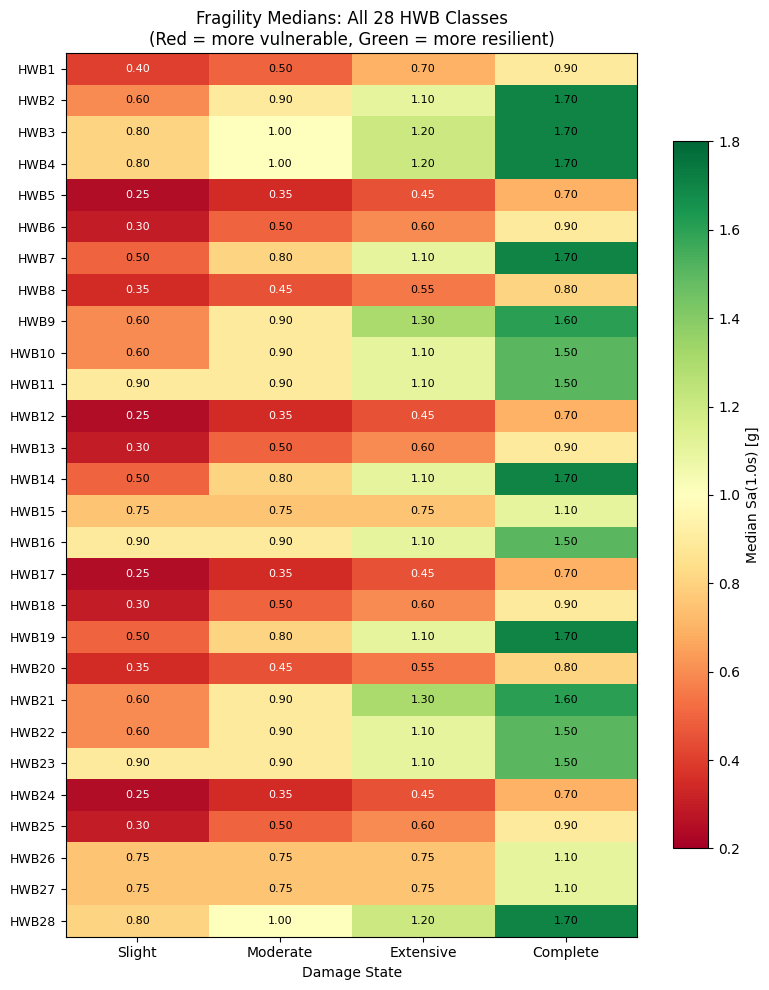

In [3]:
# Visualize all 28 classes: median Sa(1.0s) heatmap
# This shows vulnerability at a glance — lower medians = more vulnerable
median_cols = ["slight_median", "moderate_median", "extensive_median", "complete_median"]
heatmap_data = frag_csv.set_index("HWB_Class")[median_cols]
heatmap_data.columns = ["Slight", "Moderate", "Extensive", "Complete"]

fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(heatmap_data.values, cmap="RdYlGn", aspect="auto", vmin=0.2, vmax=1.8)
ax.set_xticks(range(4))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticks(range(len(heatmap_data)))
ax.set_yticklabels(heatmap_data.index, fontsize=9)
# Annotate cells with median values
for i in range(len(heatmap_data)):
    for j in range(4):
        val = heatmap_data.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8,
                color="white" if val < 0.5 else "black")
cbar = plt.colorbar(im, ax=ax, label="Median Sa(1.0s) [g]", shrink=0.8)
ax.set_title("Fragility Medians: All 28 HWB Classes\n(Red = more vulnerable, Green = more resilient)")
ax.set_xlabel("Damage State")
plt.tight_layout()
plt.show()

## Step 2: NBI Bridge → HWB Class → Parameter Lookup

This is the key matching step. Each NBI bridge record has material, design type,
span count, and year built. The `classify_nbi_to_hazus()` function maps these
attributes to one of 28 HWB classes. We then look up the fragility parameters
from the database for that class.

**Workflow for a single bridge:**
1. Read NBI record → material="concrete", design="other", spans=3, year=1966
2. Classification rule → HWB17 (Multi-Col. Bent, Prestressed Concrete, Conventional)
3. Look up HAZUS_BRIDGE_FRAGILITY["HWB17"] → get median & beta for 4 damage states

In [4]:
# Load NBI and classify
cfg = load_config(PROJECT_ROOT / "config.yaml")
nbi = load_nbi(PROJECT_ROOT / "data" / "CA24.txt", northridge_bbox=cfg.region)
nbi = classify_nbi_to_hazus(nbi)

# Pick a specific bridge to demonstrate the full lookup
bridge = nbi.iloc[5]  # 52 0273
print("=" * 60)
print("STEP-BY-STEP: NBI Record → Fragility Parameters")
print("=" * 60)

# Step A: Show the raw NBI record
print(f"\n--- A. NBI Bridge Record ---")
print(f"  Structure #:  {bridge['structure_number']}")
print(f"  Material:     {bridge['material']} (code {bridge['material_code']})")
print(f"  Design type:  {bridge['design_type']} (code {bridge['design_code']})")
print(f"  Num spans:    {bridge['num_spans']}")
print(f"  Year built:   {bridge['year_built']}")

# Step B: Show the classification result
hwb = bridge["hwb_class"]
print(f"\n--- B. Hazus Classification ---")
print(f"  Assigned class: {hwb}")
print(f"  Class name:     {HAZUS_BRIDGE_FRAGILITY[hwb]['name']}")

# Step C: Look up fragility parameters from database
params = HAZUS_BRIDGE_FRAGILITY[hwb]["damage_states"]
print(f"\n--- C. Fragility Parameters (from database) ---")
print(f"  {'Damage State':<12} {'Median (g)':>10} {'Beta':>6}")
print(f"  {'-'*30}")
for ds in DAMAGE_STATE_ORDER:
    p = params[ds]
    print(f"  {ds:<12} {p['median']:>10.2f} {p['beta']:>6.1f}")

STEP-BY-STEP: NBI Record → Fragility Parameters

--- A. NBI Bridge Record ---
  Structure #:  52 0273
  Material:     concrete (code 2)
  Design type:  other (code 5)
  Num spans:    3
  Year built:   1966

--- B. Hazus Classification ---
  Assigned class: HWB17
  Class name:     Multi-Col. Bent, Simple Support - Prestressed Concrete, Conventional (Non-CA)

--- C. Fragility Parameters (from database) ---
  Damage State Median (g)   Beta
  ------------------------------
  slight             0.25    0.6
  moderate           0.35    0.6
  extensive          0.45    0.6
  complete           0.70    0.6


## Step 3: Plot Fragility Curve for This Bridge

Now we use the retrieved parameters to plot the fragility curves for this specific bridge.
A vertical dashed line marks the actual Sa(1.0s) at the bridge site, showing how
the exceedance probabilities are read off the curves.

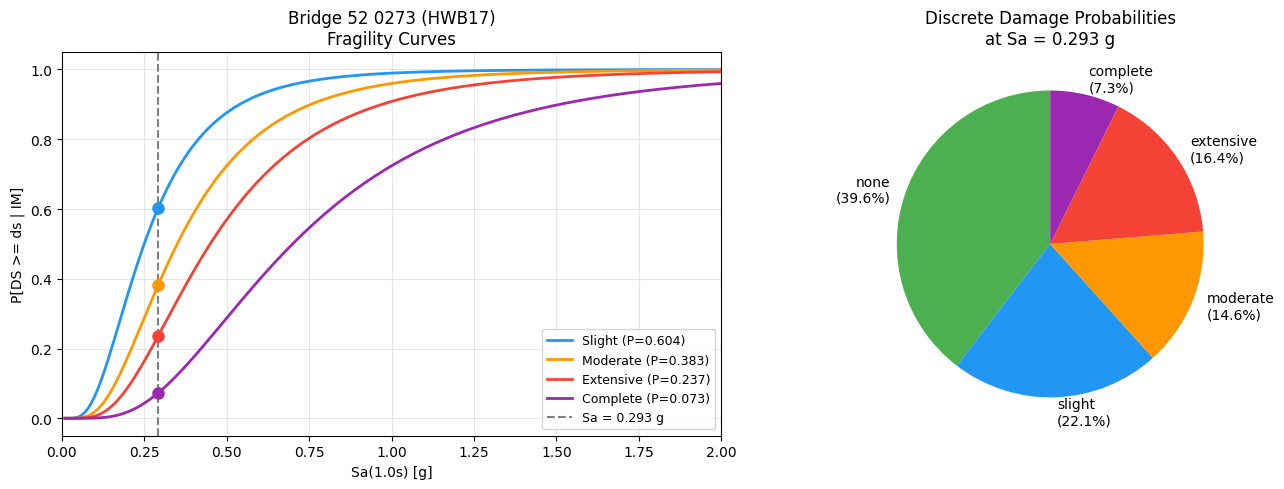


Bridge 52 0273: HWB17 (Multi-Col. Bent, Simple Support - Prestressed Concrete, Conventional (Non-CA))
Sa(1.0s) = 0.2929 g
Most likely damage state: none (39.6%)


In [5]:
# Get this bridge's actual Sa from ShakeMap
grid = load_shakemap(PROJECT_ROOT / "data" / "grid.xml")
im_col = IM_COLUMN_MAP.get(cfg.im_type, "PSA10")
bridge_sa = float(interpolate_im(
    grid["LAT"].values, grid["LON"].values, grid[im_col].values,
    np.array([bridge["latitude"]]), np.array([bridge["longitude"]]),
    method="nearest",
)[0])

# Plot fragility curves using the looked-up parameters
im_range = np.linspace(0.01, 2.0, 200)
colors = {"slight": "#2196F3", "moderate": "#FF9800",
          "extensive": "#F44336", "complete": "#9C27B0"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Exceedance curves with vertical Sa line
curves = compute_all_curves(hwb, im_range)
for ds in DAMAGE_STATE_ORDER:
    exc_at_sa = float(fragility_curve(np.array([bridge_sa]), params[ds]["median"], params[ds]["beta"])[0])
    ax1.plot(im_range, curves[ds], label=f"{ds.capitalize()} (P={exc_at_sa:.3f})",
             color=colors[ds], lw=2)
    ax1.plot(bridge_sa, exc_at_sa, "o", color=colors[ds], markersize=8, zorder=5)

ax1.axvline(bridge_sa, color="gray", ls="--", lw=1.5, label=f"Sa = {bridge_sa:.3f} g")
ax1.set_xlabel("Sa(1.0s) [g]")
ax1.set_ylabel("P[DS >= ds | IM]")
ax1.set_title(f"Bridge {bridge['structure_number']} ({hwb})\nFragility Curves")
ax1.legend(fontsize=9, loc="lower right")
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 2.0)

# Right: Discrete damage probabilities (pie chart)
probs = damage_state_probabilities(bridge_sa, hwb)
ds_labels = list(probs.keys())
ds_values = list(probs.values())
pie_colors = ["#4CAF50", "#2196F3", "#FF9800", "#F44336", "#9C27B0"]
ax2.pie(ds_values, labels=[f"{ds}\n({p:.1%})" for ds, p in zip(ds_labels, ds_values)],
        colors=pie_colors, startangle=90, textprops={"fontsize": 10})
ax2.set_title(f"Discrete Damage Probabilities\nat Sa = {bridge_sa:.3f} g")

plt.tight_layout()
plt.show()

print(f"\nBridge {bridge['structure_number']}: {hwb} ({HAZUS_BRIDGE_FRAGILITY[hwb]['name']})")
print(f"Sa(1.0s) = {bridge_sa:.4f} g")
print(f"Most likely damage state: {max(probs, key=probs.get)} ({max(probs.values()):.1%})")

## Step 4: Compare Fragility Across Classes

Compare fragility curves for 3 representative classes side by side to see how
bridge type affects vulnerability. Also show damage probabilities at a fixed Sa.

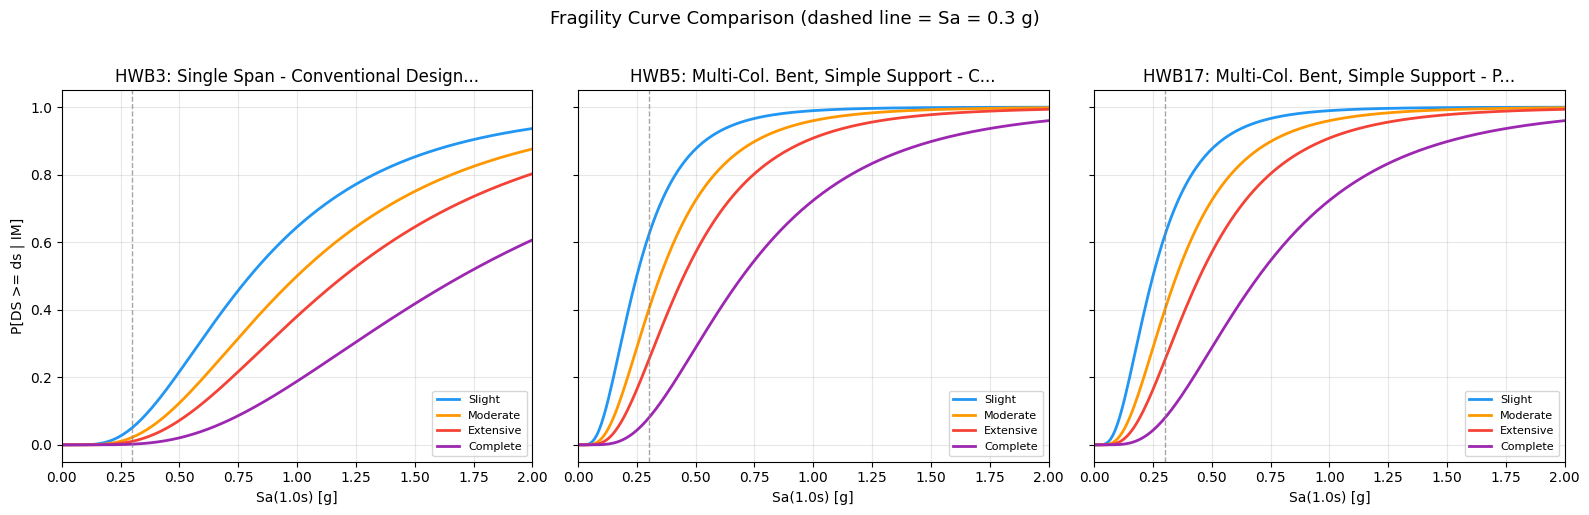


Damage probabilities at Sa = 0.3 g:
Class        None   Slight Moderate  Extensive   Complete
--------------------------------------------------------
HWB3        0.949    0.029    0.012      0.009      0.002
HWB5        0.381    0.221    0.149      0.171      0.079
HWB17       0.381    0.221    0.149      0.171      0.079


In [6]:
# Compare 3 HWB classes at a fixed Sa level
example_classes = ["HWB3", "HWB5", "HWB17"]
sa_compare = 0.3

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, hwb_c in zip(axes, example_classes):
    curves_c = compute_all_curves(hwb_c, im_range)
    for ds in DAMAGE_STATE_ORDER:
        ax.plot(im_range, curves_c[ds], label=ds.capitalize(), color=colors[ds], lw=2)
    ax.axvline(sa_compare, color="gray", ls="--", lw=1, alpha=0.7)
    ax.set_xlabel("Sa(1.0s) [g]")
    ax.set_title(f"{hwb_c}: {HAZUS_BRIDGE_FRAGILITY[hwb_c]['name'][:35]}...")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 2.0)
axes[0].set_ylabel("P[DS >= ds | IM]")
plt.suptitle(f"Fragility Curve Comparison (dashed line = Sa = {sa_compare} g)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Show damage probabilities at this Sa for each class
print(f"\nDamage probabilities at Sa = {sa_compare} g:")
print(f"{'Class':<8} {'None':>8} {'Slight':>8} {'Moderate':>8} {'Extensive':>10} {'Complete':>10}")
print("-" * 56)
for hwb_c in example_classes:
    p = damage_state_probabilities(sa_compare, hwb_c)
    print(f"{hwb_c:<8} {p['none']:>8.3f} {p['slight']:>8.3f} {p['moderate']:>8.3f} "
          f"{p['extensive']:>10.3f} {p['complete']:>10.3f}")

## Step 5: Damage Probabilities for All Bridges

In [7]:
# Load bridges with IM values
cfg = load_config(PROJECT_ROOT / "config.yaml")
grid = load_shakemap(PROJECT_ROOT / "data" / "grid.xml")
nbi = load_nbi(PROJECT_ROOT / "data" / "CA24.txt", northridge_bbox=cfg.region)
nbi = classify_nbi_to_hazus(nbi)

im_col = IM_COLUMN_MAP.get(cfg.im_type, "PSA10")
nbi["sa"] = interpolate_im(
    grid["LAT"].values, grid["LON"].values, grid[im_col].values,
    nbi["latitude"].values, nbi["longitude"].values,
    method="nearest",
)

# Compute damage probabilities for each bridge
all_probs = []
for _, row in nbi.iterrows():
    p = damage_state_probabilities(row["sa"], row["hwb_class"])
    p["structure_number"] = row["structure_number"]
    p["hwb_class"] = row["hwb_class"]
    p["sa"] = row["sa"]
    all_probs.append(p)

dmg_df = pd.DataFrame(all_probs)
print(f"Damage probability DataFrame: {dmg_df.shape}")
display(dmg_df.head(10))

Damage probability DataFrame: (2953, 8)


,none,slight,moderate,extensive,complete,structure_number,hwb_class,sa
0,0.219918,0.196259,0.165886,0.245240,0.172697,52 0036,HWB17,0.3974
1,0.581961,0.136683,0.154131,0.067664,0.059562,52 0037,HWB1,0.3533
2,0.618269,0.187311,0.094249,0.078321,0.021849,52 0046,HWB17,0.2087
3,0.442414,0.218857,0.136811,0.143847,0.058070,52 0237,HWB17,0.2727
4,0.822118,0.133953,0.031304,0.011102,0.001523,52 0268E,HWB7,0.2873
5,0.395909,0.220795,0.146205,0.163851,0.073239,52 0273,HWB17,0.2929
6,0.522987,0.208870,0.118344,0.111741,0.038058,52 0274,HWB17,0.2415
7,0.097996,0.134007,0.144982,0.286860,0.336156,52 0282,HWB17,0.5431
8,0.119643,0.149309,0.152912,0.283283,0.294854,52 0283,HWB17,0.5065
9,0.032378,0.066817,0.093695,0.255034,0.552077,52 0299,HWB17,0.7572


## Step 6: Damage Distribution Bar Chart

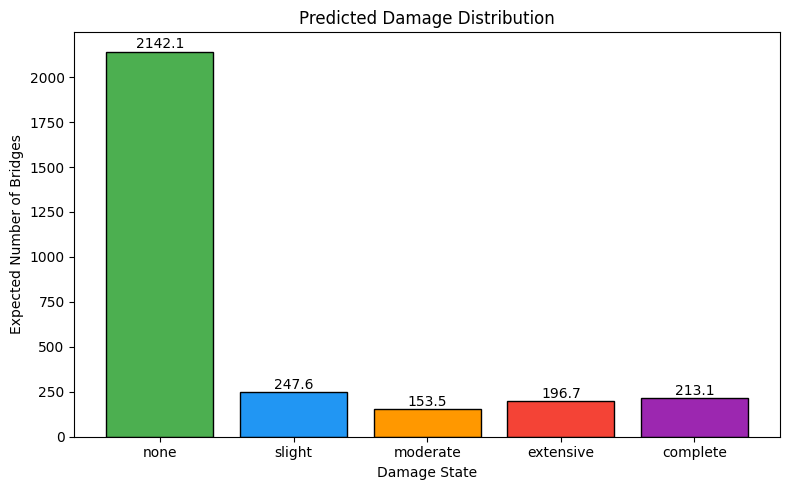

Total bridges: 2953
  none        : 2142.1 (72.5%)
  slight      :  247.6 (8.4%)
  moderate    :  153.5 (5.2%)
  extensive   :  196.7 (6.7%)
  complete    :  213.1 (7.2%)


In [8]:
ds_order = ["none", "slight", "moderate", "extensive", "complete"]
expected_counts = {ds: dmg_df[ds].sum() for ds in ds_order}

fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = ["#4CAF50", "#2196F3", "#FF9800", "#F44336", "#9C27B0"]
bars = ax.bar(ds_order, expected_counts.values(), color=bar_colors, edgecolor="k")

# Add count labels
for bar, count in zip(bars, expected_counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{count:.1f}", ha="center", va="bottom", fontsize=10)

ax.set_xlabel("Damage State")
ax.set_ylabel("Expected Number of Bridges")
ax.set_title("Predicted Damage Distribution")
plt.tight_layout()
plt.show()

print(f"Total bridges: {len(nbi)}")
for ds, cnt in expected_counts.items():
    print(f"  {ds:<12}: {cnt:6.1f} ({cnt/len(nbi)*100:.1f}%)")

## Summary

In this notebook we:
1. **Loaded fragility parameters** from `hazus_bridge_fragility_params.csv` (28 HWB classes × 4 damage states)
2. **Visualized the full parameter database** as a heatmap (red = vulnerable, green = resilient)
3. **Demonstrated the NBI → HWB → parameter lookup** workflow for a single real bridge
4. **Plotted fragility curves** for that bridge with actual Sa marked, plus discrete damage pie chart
5. **Compared fragility across 3 HWB classes** at the same Sa level
6. **Computed portfolio-level damage distribution** for all 2,953 bridges

**Next:** [05_loss.ipynb](05_loss.ipynb) — Per-bridge and portfolio loss calculation